# Supplementary File 3: Tissue Thickness Quantification
for ``Four-Fold Expansion Microscopy of Tissue"
by Corban Swain, Sapna Sinha, and Ed Boyden

## 1. Setting Up Repository and Opening the Notebook
1. You will need to install and set up the following software before continuing:
   - [ ] [**git** https://git-scm.com/](https://git-scm.com/)
   - [ ] [**mamba** https://mamba.readthedocs.io](https://mamba.readthedocs.io/en/latest/installation/mamba-installation.html)
   - [ ] [**Fiji (ImageJ)** https://imagej.net/software/fiji/downloads](https://imagej.net/software/fiji/downloads)
         (version 1.54p was used)
2. Clone the
   [**ExM-Demo-Figures** repository (https://github.com/CorbanSwain/ExM-Demo-Figures)](https://github.com/CorbanSwain/ExM-Demo-Figures)
   into a directory (e.g. `~/ExM-Demo-Figures`) on your computer. Then initialize and update the submodules.
   ```
   cd ~
   git clone https://github.com/CorbanSwain/ExM-Demo-Figures ~/ExM-Demo-Figures
   git submodule update --init
   ```
4. Set up the Python environment according to the environment configuration provided in the repository.
   ```
   cd ~/ExM-Demo-Figures/envs/
   mamba create -f exm-demo-fig-py3.12-env.yml
   ```
5. Then run JupyterLab and open this notebook via the JupyterLab interface.
   ```
   cd ~/ExM-Demo-Figures/source
   mamba activate exm-demo-fig-py3.12-env 
   jupyter lab supplementary_file_xx-thickness-analysis.ipynb
   ```

In [ ]:
### ?. Acquisition and export of images.

## ?. Analysis of Z-Stacks with Python
Run the following cells proces the images

### ?.1 Package Imports

In [16]:
# 3.1.1 base and metaprogramming imports
from __future__ import annotations

import itertools as it
import os
import sys
import contextlib
from typing import Union, Any, Optional
import enum
from unittest.mock import right

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal as sig
import skspatial.objects as skso
import skspatial.plotting as sksplt
import tifffile
from numpy.ma.core import left_shift
from seaborn import heatmap

# 3.1.2 ipynb-specific imports
try:
    import ipynbname
except Exception as e:
    warnings.warn(f'`ipynbname` module import failed with error: {e!r}')
    ipynbname = None
    
if ipynbname is not None:
    _file = ipynbname.path()
else:
    # manually set the full path to the current notebook below if `ipynbname` 
    # import fails
    _file = ''

# 3.1.3 key path variables and management
source_dir = os.path.split(_file)[0]
repo_dir = os.path.abspath(os.path.join(source_dir, '..'))
data_dir = os.path.join(repo_dir, 'data')
figure_dir = os.path.join(repo_dir, 'figures')
if source_dir not in sys.path:
    sys.path.append(source_dir)

print('Imports done.')

Imports done.


### 3.2 Plotting Defaults

In [3]:
# 3.2.1 load custom fonts, if available
custom_fonts = [
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Black.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Bold.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Roman.otf',
    'C:\\Windows\\Fonts\\Linotype - HelveticaLTPro-Oblique.otf']
for font_path in custom_fonts:
    if os.path.exists(font_path):
        print(f'Adding font: "{os.path.split(font_path)[-1]}" to mpl.')
        mpl.font_manager.fontManager.addfont(font_path)

# 3.2.2 set plotting style
sns.set_style(
    'ticks',
    {'font.sans-serif': [
        'Helvetica LT Pro', 'Helvetica', 'Arial', 'sans-serif'],
     'mathtext.fontset': ['cm',],
     'axes.linewidth': 2})

# 3.2.3 set axis and figure defaults
axes_lw = 1.25
mpl.rcParams['axes.linewidth'] = axes_lw
mpl.rcParams['xtick.major.width'] = axes_lw
mpl.rcParams['xtick.minor.width'] = axes_lw
mpl.rcParams['ytick.major.width'] = axes_lw
mpl.rcParams['ytick.minor.width'] = axes_lw

mpl.rcParams['axes.facecolor'] = 'none'

mpl.rcParams['figure.frameon'] = False
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['figure.edgecolor'] = 'none'

print('Plotting defaults set; done.')

Adding font: "Linotype - HelveticaLTPro-Black.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Bold.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Roman.otf" to mpl.
Adding font: "Linotype - HelveticaLTPro-Oblique.otf" to mpl.
Plotting defaults set; done.


### 3.3 Filepaths and Other Parameter Inputs

In [4]:
# 3.3.1 filepath names
# Edit these fields to match the files you wish to analyze.
z_depth_dname = 'z-depth-analysis'
normal_fname = 'normal-nhs-z-stack.tif'
expanded_fname = 'expanded-nhs-z-stack.tif'

figure_name = 'z_depth_analysis'  # output figure name

MAG_KEY = 'magnification'
XY_PITCH_UM_KEY = 'xy_pitch_um'
Z_PITCH_UM_KEY = 'z_pitch_um'
normal_md = {
    MAG_KEY: 40,
    XY_PITCH_UM_KEY: 0.1696231,
    Z_PITCH_UM_KEY: 0.4}
expanded_md = {
    MAG_KEY: 20,
    XY_PITCH_UM_KEY: 0.3523270,
    Z_PITCH_UM_KEY: 2.5}

print('Parameters set; done.')

Parameters set; done.


In [5]:
class Dim(str, enum.Enum):
    X = 'x'
    Y = 'y'
    Z = 'z'

    @property
    def nd2_str(self):
        if self is Dimension.X:
            return 'x'
        elif self is Dimension.Y:
            return 'y'
        elif self is Dimension.Z:
            return 'z'

    @property
    def is_numeric(self):
        return self in (Dim.X, Dim.Y, Dim.Z)

    def __repr__(self):
        return f'Dim(\'{self:s}\')'

    def __str__(self):
        return self.value

class CoordinateVector:
    # magic methods
    def __init__(self,
                 vector: np.ndarray,
                 unit: Optional[str] = None):
        self.vector: np.ndarray = vector
        self.unit: Optional[str] = unit

    def __eq__(self, other: CoordinateVector):
        if not isinstance(other, CoordinateVector):
            return False

        if not (len(self.vector) == len(other.vector)):
            return False

        if not (self.unit == other.unit):
            return False

        return all(si == oi for si, oi in zip(self.vector, other.vector))

    def __repr__(self):
        return (f'Coord([{self.vector[0]}, ...], ' 
                f'len={len(self.vector):d}, unit=\'{self.unit}\')')

    # class methods
    @classmethod
    def from_pitch_and_len(cls,
                           pitch: float,
                           length: int, 
                           unit: Optional[str] = None,
                           zero_center: bool = False):
        adj = (-1 * ((float(length) / 2) - 0.5)) if zero_center else 0
        vector = (np.arange(length) + adj) * pitch
        return cls(vector, unit=unit)
        

    # properties
    @property
    def median_pitch(self):
        return np.median(np.diff(self.vector))

    # general methods
    def flip(self, in_place: bool = False):
        if in_place:
            self.vector = np.flip(self.vector, axis=0)
        else:
            new_cv = self.__class__(np.flip(self.vector, axis=0),
                                    unit=self.unit)
            return new_cv

class TiffKeys:
    BITS_PER_SAMPLE = 'BitsPerSample'

class TIFFDataset(object):
    """
    Helper class for working with .tiff image files
    """
    # magic methods
    def __init__(self,
                 path: str | bytes | os.PathLike[Any],
                 name: str,
                 xy_pitch: float,
                 z_pitch: Optional[float],
                 pitch_unit: str,
                 dimensions: tuple[Dim, ...]
                 ):

        self.path = path
        self.name = name
        self.xy_pitch = xy_pitch
        self.z_pitch = z_pitch
        self.pitch_unit = pitch_unit
        self.dimensions = dimensions

        # set by other initializers
        self.bits_per_sample: Optional[int] = None
        self.coordinates: Optional[dict[Dim, CoordinateVector]] = None
        self._metadata: tifffile.TiffTags
        self._init_from_tifffile()

        assert len(self.dimensions) == self.ndim, \
            ('dimensions must be a tuple with length equal to '
             'the number of dimensions in the image data')

    def __repr__(self):
        return (
            f'{self.__class__.__name__:s}(path="{self.path}",'
            f' name="{self.name}")')

    def __str__(self):
        return (
            f'{self.__class__.__name__:s}(name="{self.name}")'
            f'\n   with shape {self.shape}'
            f'\n   and spatial extents'
            f' {" x ".join('{:.3f}'.format(x) for x in self.spatial_shape)}'
            f' {self.pitch_unit:s}'
            f'\n   in {', '.join(str(d) for d in self.dimensions)}')

    # methods
    def generate_coordinates(self,
                             zero_center: bool | dict[Dim, bool] = False) -> None:
        coordinates = {}
        for i, dim in enumerate(self.dimensions):
            if dim in (Dim.X, Dim.Y):
                pitch_um = self.xy_pitch
            if dim is Dim.Z:
                pitch_um = self.z_pitch
            # check if zero_center is a dict
            if isinstance(zero_center, dict):
                zc = zero_center.get(dim, False)
            coordinates[dim] = CoordinateVector.from_pitch_and_len(
                pitch_um,
                self.shape[i],
                unit=self.pitch_unit,
                zero_center=zc)
        self.coordinates = coordinates
    
    # properties
    @property
    def ndim(self) -> int:
        return self.image_ndarray.ndim

    @property
    def shape(self) -> tuple[int, ...]:
        return self.image_ndarray.shape

    @property
    def spatial_shape(self) -> tuple[float, ...]:
        shape_arr = np.array(self.shape).astype(float)
        for i, dim in enumerate(self.dimensions):
            if dim in (Dim.X, Dim.Y):
                shape_arr[i] *= self.xy_pitch
            if dim is Dim.Z:
                shape_arr[i] *= self.z_pitch
        return tuple(shape_arr)

    @property
    def shape_dict(self) -> dict[Dim, int]:
        shape_dict = dict()
        for i, dim in enumerate(self.dimensions):
            shape_dict[dim] = self.shape[i]
        return shape_dict

    @property
    def image_ndarray(self) -> np.ndarray:
        """
        ndarray of the image data
        """
        return self._image_ndarray

    @property
    def metadata(self) -> tifffile.TiffTags:
        """
        metadata from tiff file as tifffile.TiffTags
        """
        return self._metadata

    # protected methods
    @contextlib.contextmanager
    def _tifffile(self) -> tifffile.TiffFile:
        """
        wrapper for tifffile.TiffFile context using the object's path
        """
        with tifffile.TiffFile(self.path) as tif:
            yield tif

    def _init_from_tifffile(self) -> None:
        """
        initializes the object attributes from a .tiff file on disk
        """
        self._load_image_data()
        with self._tifffile() as tif:
            self._metadata = tif.pages[0].tags
            self.bits_per_sample = (
                    self.metadata[TiffKeys.BITS_PER_SAMPLE].value)

    def _load_image_data(self) -> None:
        """
        loads image data from the tifffile into an ndarray attribute of the
        object.
        """
        print(f'Loading all image data from tiff file at "{self.path:s}".')
        with self._tifffile() as tif:
            self._image_ndarray = tif.asarray()

print('Helper classes loaded; done.')

Helper classes loaded; done.


### ?.? Loading and Processing Data Tables

In [6]:
# 3.4.1 generate full paths to files
z_depth_dir = os.path.join(data_dir, z_depth_dname)
normal_tif_path = os.path.join(z_depth_dir, normal_fname)
expanded_tif_path = os.path.join(z_depth_dir, expanded_fname)
print('Set full paths')

Set full paths


In [7]:
normal_dset = TIFFDataset(
    normal_tif_path,
    name='Normal',
    xy_pitch=normal_md[XY_PITCH_UM_KEY],
    z_pitch=normal_md[Z_PITCH_UM_KEY],
    pitch_unit='micron',
    dimensions=(Dim.Z, Dim.Y, Dim.X))
normal_dset.generate_coordinates(zero_center={Dim.X: True, Dim.Y: True})
print(f'normal_dset : {normal_dset}')
print(f'   normal_dset.coordinates : {normal_dset.coordinates}')

expanded_dset = TIFFDataset(
    expanded_tif_path,
    name='Expanded',
    xy_pitch=expanded_md[XY_PITCH_UM_KEY],
    z_pitch=expanded_md[Z_PITCH_UM_KEY],
    pitch_unit='micron',
    dimensions=(Dim.Z, Dim.Y, Dim.X))
expanded_dset.generate_coordinates(zero_center={Dim.X: True, Dim.Y: True})
print(f'expanded_dset : {expanded_dset}')
print(f'  expanded_dset.coordinates : {expanded_dset.coordinates}')

Loading all image data from tiff file at "I:\CorbanSwain\repos\exm-demo-figures\data\z-depth-analysis\normal-nhs-z-stack.tif".
normal_dset : TIFFDataset(name="Normal")
   with shape (278, 2048, 2048)
   and spatial extents 111.200 x 347.388 x 347.388 micron
   in z, y, x
   normal_dset.coordinates : {Dim('z'): Coord([0.0, ...], len=278, unit='micron'), Dim('y'): Coord([-173.60924285, ...], len=2048, unit='micron'), Dim('x'): Coord([-173.60924285, ...], len=2048, unit='micron')}
Loading all image data from tiff file at "I:\CorbanSwain\repos\exm-demo-figures\data\z-depth-analysis\expanded-nhs-z-stack.tif".
expanded_dset : TIFFDataset(name="Expanded")
   with shape (127, 2048, 2048)
   and spatial extents 317.500 x 721.566 x 721.566 micron
   in z, y, x
  expanded_dset.coordinates : {Dim('z'): Coord([0.0, ...], len=127, unit='micron'), Dim('y'): Coord([-360.60668450000003, ...], len=2048, unit='micron'), Dim('x'): Coord([-360.60668450000003, ...], len=2048, unit='micron')}


 ### ?.? Section header

In [8]:
# convert the tiff stacks into long tables tagged by x, y, z, and sample

analysis_extent_um = (-150, 150)
analysis_averaging_window_um = 50
analysis_border_vec = np.arange(
    analysis_extent_um[0],
    analysis_extent_um[1] + analysis_averaging_window_um,
    analysis_averaging_window_um)
analysis_num_rows = len(analysis_border_vec) - 1
analysis_loc_vec = analysis_border_vec[:-1] + (analysis_averaging_window_um / 2)

print(f'{analysis_border_vec = }')
print(f'{analysis_num_rows = }')

analysis_border_vec = array([-150, -100,  -50,    0,   50,  100,  150])
analysis_num_rows = 6


In [9]:
def normalize_vector(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

In [10]:
long_df = None

for dset in (normal_dset, expanded_dset):
    print(f'Processing {dset.name:s}...')
    x_vec = dset.coordinates[Dim.X].vector
    y_vec = dset.coordinates[Dim.Y].vector
    z_vec = dset.coordinates[Dim.Z].vector

    # get the index for each border location
    x_idxs = np.searchsorted(
        x_vec,
        analysis_border_vec)
    y_idxs = np.searchsorted(
        y_vec,
        analysis_border_vec)

    im_data = dset.image_ndarray

    iterator = it.product(range(analysis_num_rows), range(analysis_num_rows))
    for ix, iy in iterator:
        im_sample = im_data[
            :,
            y_idxs[iy]:y_idxs[iy + 1],
            x_idxs[ix]:x_idxs[ix + 1]]
        im_sample = normalize_vector(
            np.average(im_sample, axis=(1, 2), keepdims=False))

        new_df = pd.DataFrame({
            'values': im_sample,
            'x': analysis_loc_vec[ix],
            'ix': ix,
            'y': analysis_loc_vec[iy],
            'iy': iy,
            'z': z_vec,
            'loc_id': f'{ix + (iy * analysis_num_rows)}',
            'sample': dset.name,})
        if long_df is None:
            long_df = new_df
            continue
        long_df = pd.concat([long_df, new_df], axis=0, ignore_index=True)



long_df.head(2)

Processing Normal...
Processing Expanded...


,values,x,ix,y,iy,z,loc_id,sample
0,0.086486,-125.0,0,-125.0,0,0.0,0,Normal
1,0.067378,-125.0,0,-125.0,0,0.4,0,Normal


### 3.6 Compute Median Nuclei Sizes and *n*

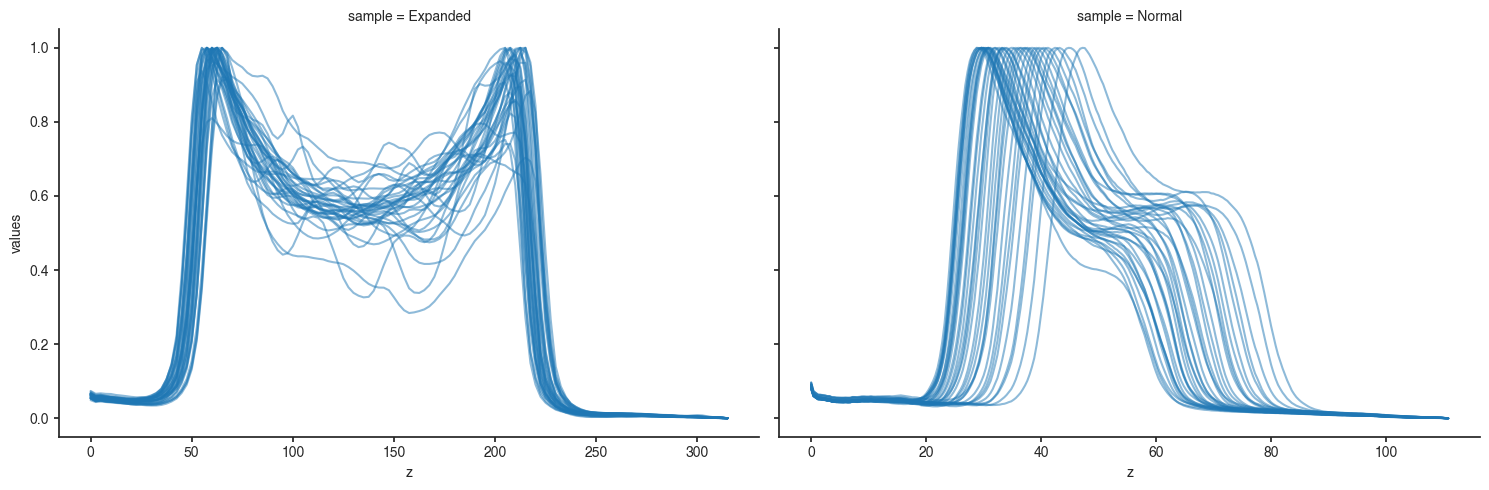

In [11]:
g = sns.FacetGrid(
    long_df,
    col='sample',
    col_order=[expanded_dset.name, normal_dset.name],
    sharex=False,
    sharey=True,
    margin_titles=True,
    height=5,
    aspect=1.5,
)
g.map_dataframe(
    sns.lineplot,
    'z',
    'values',
    units='loc_id',
    estimator=None,
    alpha=0.5,)

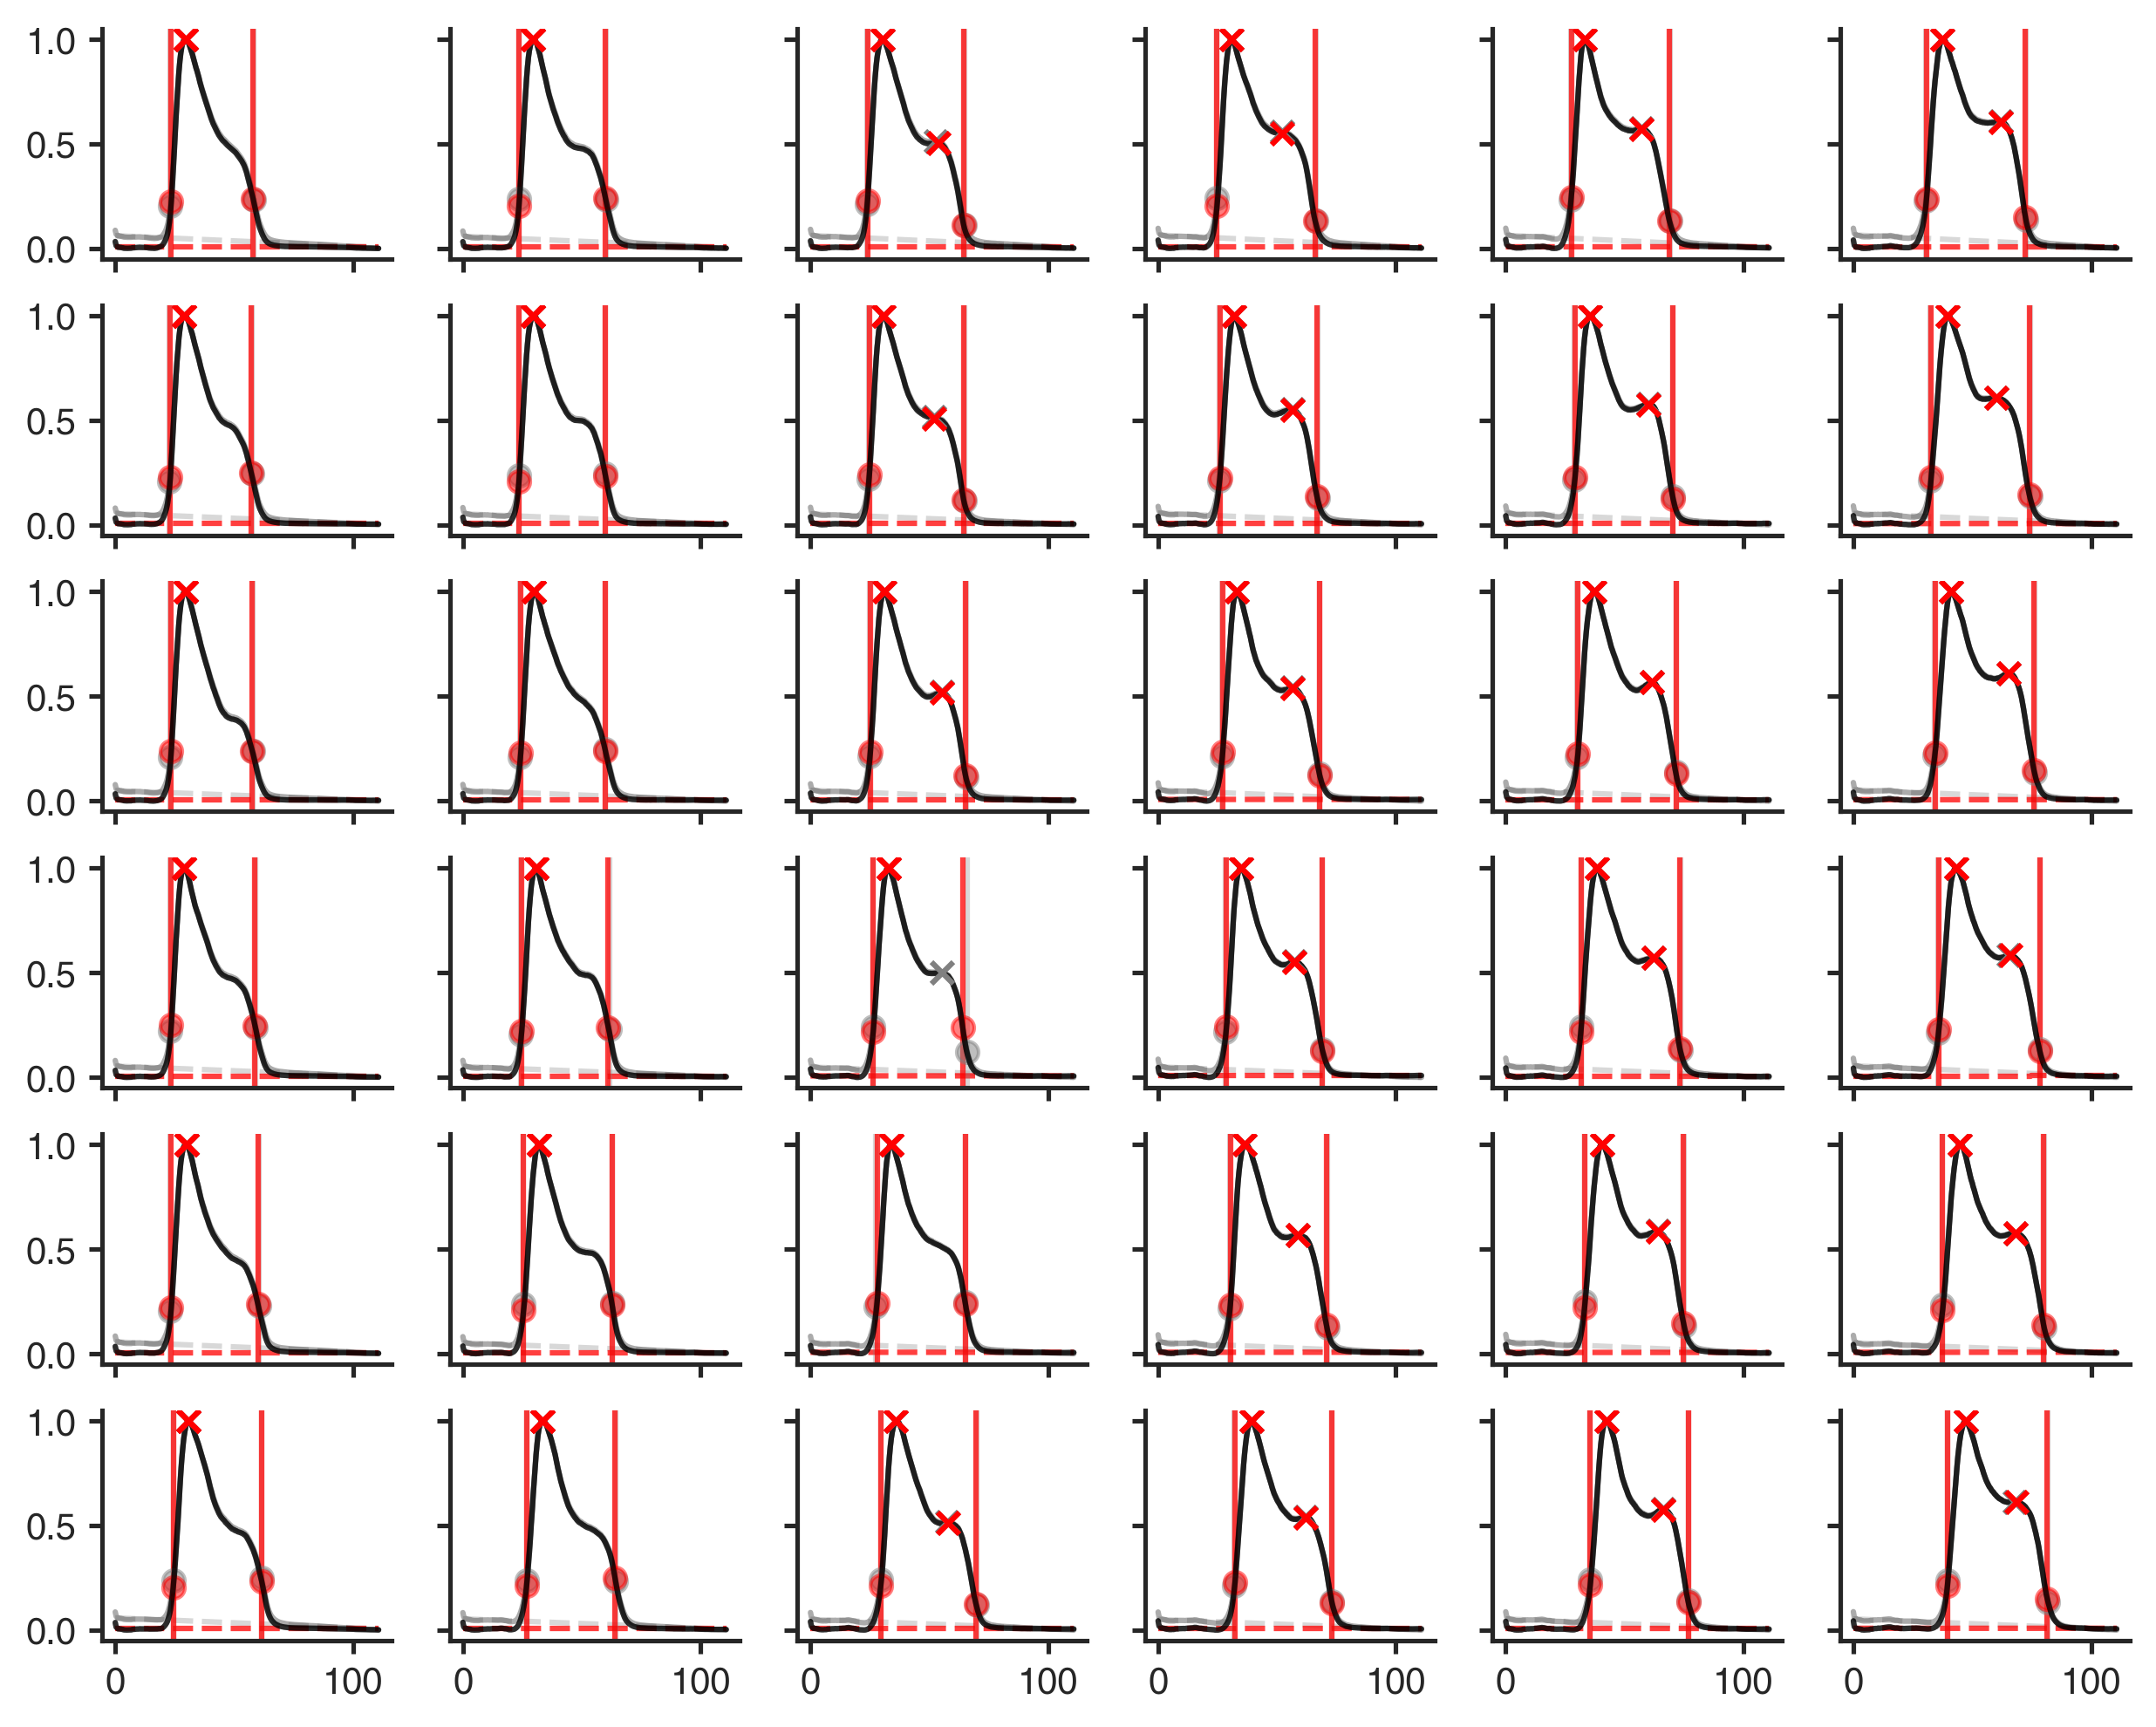

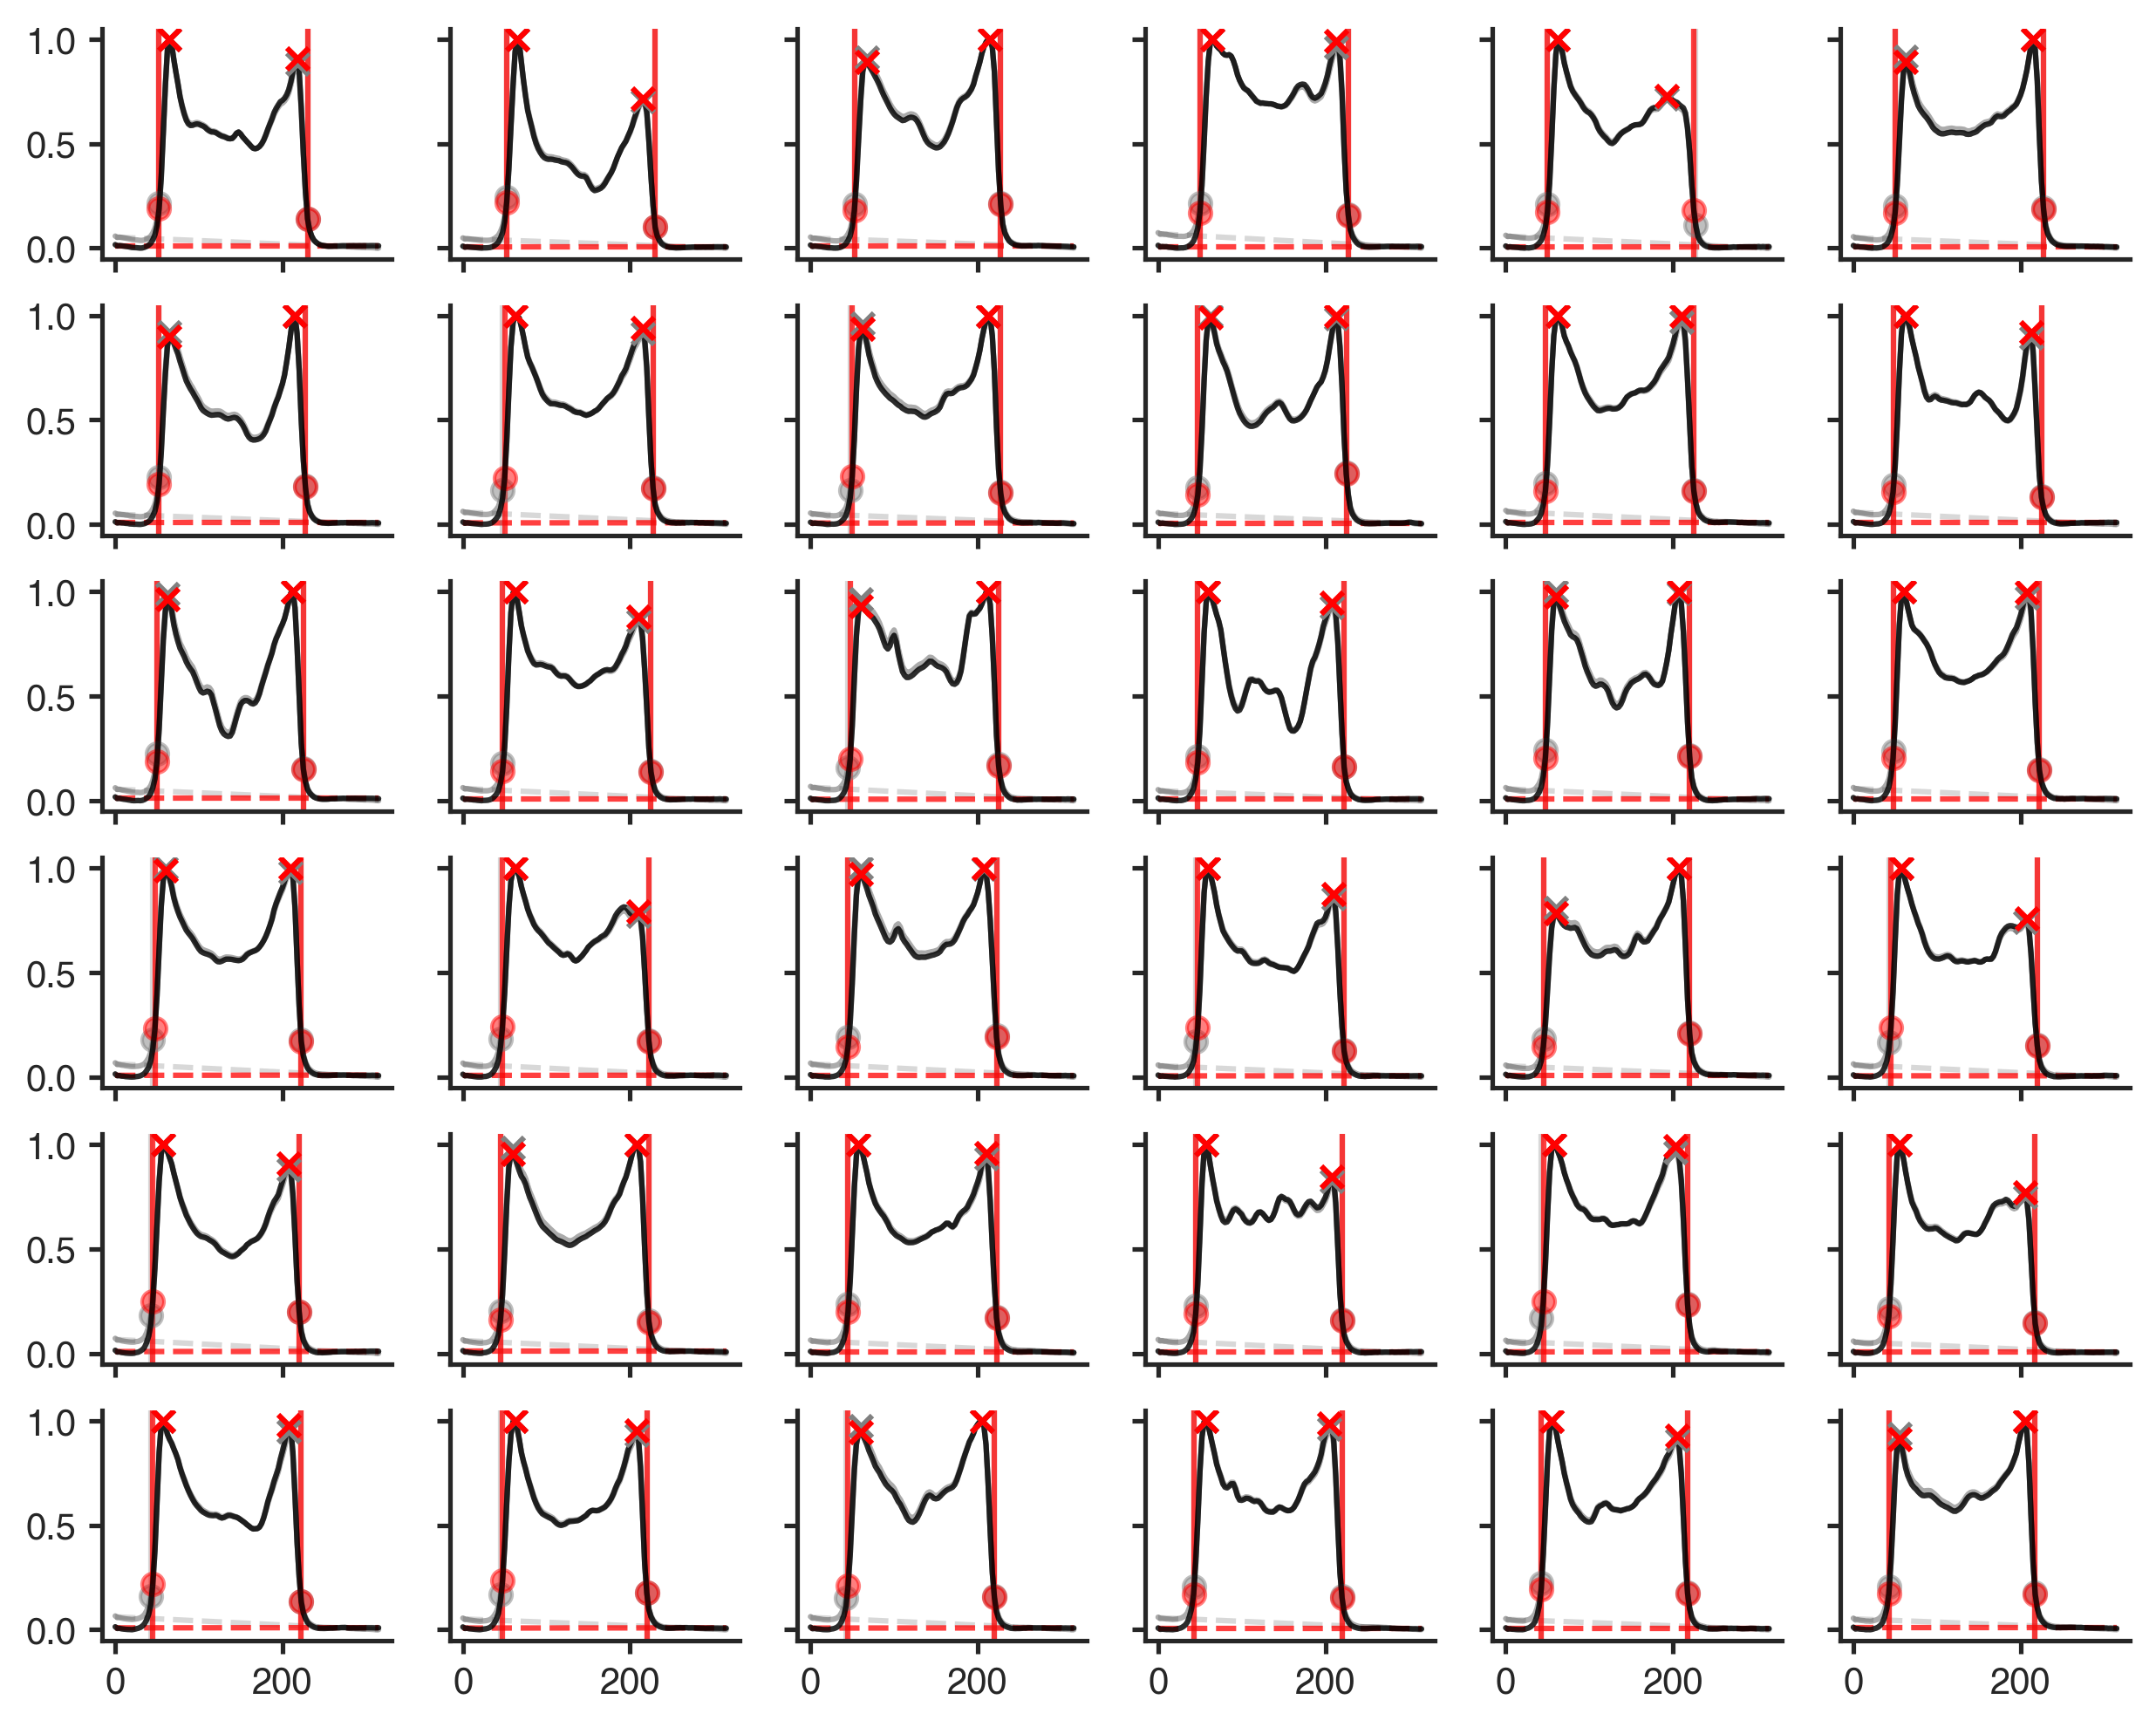

,loc_id,sample,x,y,ix,iy,z,z_loc
0,0,Normal,-125.0,-125.0,0,0,23.6,bottom
1,0,Normal,-125.0,-125.0,0,0,58.0,top
2,6,Normal,-125.0,-75.0,0,1,23.6,bottom
3,6,Normal,-125.0,-75.0,0,1,60.0,top
4,12,Normal,-125.0,-25.0,0,2,24.0,bottom
...,...,...,...,...,...,...,...,...
139,23,Expanded,125.0,25.0,5,3,220.0,top
140,29,Expanded,125.0,75.0,5,4,42.5,bottom
141,29,Expanded,125.0,75.0,5,4,217.5,top
142,35,Expanded,125.0,125.0,5,5,42.5,bottom


In [12]:
%matplotlib inline

background_threshold = 0.25
background_buffer_px = 15

plane_df = None

for sample_name in long_df['sample'].unique():
    sample_filter = long_df['sample'] == sample_name

    (fig, axs) = plt.subplots(
        len(long_df['ix'].unique()), len(long_df['iy'].unique()), sharex=True, sharey=True,
        figsize=(10, 8), dpi=300)
    axs = axs.flatten()

    for iloc, loc_id in enumerate(long_df['loc_id'].unique()):
        # print(f'Processing {sample_name:s} at {loc_id:s}...')

        loc_filter = long_df['loc_id'] == loc_id
        loc_df = long_df.loc[loc_filter & sample_filter, :]
        x_loc_um = loc_df['x'].to_numpy()[0]
        y_loc_um = loc_df['y'].to_numpy()[0]
        ix_loc = loc_df['ix'].to_numpy()[0]
        iy_loc = loc_df['iy'].to_numpy()[0]

        x = loc_df['z'].to_numpy()
        y = loc_df['values'].to_numpy()
        # print(f'...{x.shape = }, {y.shape = }')
        ax = axs[iloc]
        ax.plot(loc_df['z'], loc_df['values'],
                       c='k', zorder=1, alpha=0.33)
        sns.despine(right=True, top=True, ax=ax)

        new_y = y

        # find peaks
        for i in range(2):
            c = 'gray' if i == 0 else 'r'
            a = 0.3 if i == 0 else 0.75
            (peaks, props) = sig.find_peaks(new_y, height=0.5)


            left_peak = peaks[0]
            right_peak = peaks[-1]
            # print(f'...{left_peak = } {right_peak = }')

            ax.scatter(x[[left_peak, right_peak]],
                       new_y[[left_peak, right_peak]], c=c, marker='x',
                       zorder=3)

            left_thold = new_y[left_peak] * background_threshold
            right_thold = new_y[right_peak] * background_threshold

            left_crossing = np.where(new_y[:left_peak] < left_thold)[0][-1]
            right_crossing = np.where(new_y[right_peak:] < right_thold)[0][0] + right_peak

            ax.axvline(x[left_crossing], c=c, ls='-', alpha=a, zorder=0)
            ax.axvline(x[right_crossing], c=c, ls='-', alpha=a, zorder=0)
            ax.scatter(x[left_crossing], new_y[left_crossing], c=c, zorder=2, alpha=0.5)
            ax.scatter(x[right_crossing], new_y[right_crossing], c=c, zorder=2, alpha=0.5)

            left_buffer = left_crossing - background_buffer_px
            left_buffer = 0 if left_buffer < 0 else left_buffer
            right_buffer = right_crossing + background_buffer_px
            right_buffer = len(x) - 1 if right_buffer > (len(x) - 1) else right_buffer

            back_only_i = np.concat([range(left_buffer), range(right_buffer, len(x))])
            back_only_x = x[back_only_i]
            back_only_y = new_y[back_only_i]

            # create line of best fit for background
            (back_slope, back_intercept) = np.polyfit(back_only_x, back_only_y, 1)
            back_correct = back_slope * x + back_intercept
            ax.plot(x, back_correct, c=c, ls='--', alpha=a, zorder=-1)

            new_y = normalize_vector(new_y - back_correct)
            ax.plot(x, new_y, c='k', alpha=a, zorder=2)

        new_col = pd.Series(new_y, index=loc_df.index)
        long_df.loc[loc_df.index, 'bc_values'] = new_col

        new_df = pd.DataFrame(
            {
                'loc_id': loc_id,
                'sample': sample_name,
                'x': x_loc_um,
                'y': y_loc_um,
                'ix': ix_loc,
                'iy': iy_loc,
                'z': [x[left_crossing], x[right_crossing]],
                'z_loc': ['bottom', 'top']})
        if plane_df is None:
            plane_df = new_df
            continue
        plane_df = pd.concat([plane_df, new_df], axis=0, ignore_index=True)
plt.show()
plane_df

### 3.7 Create and Save Figure

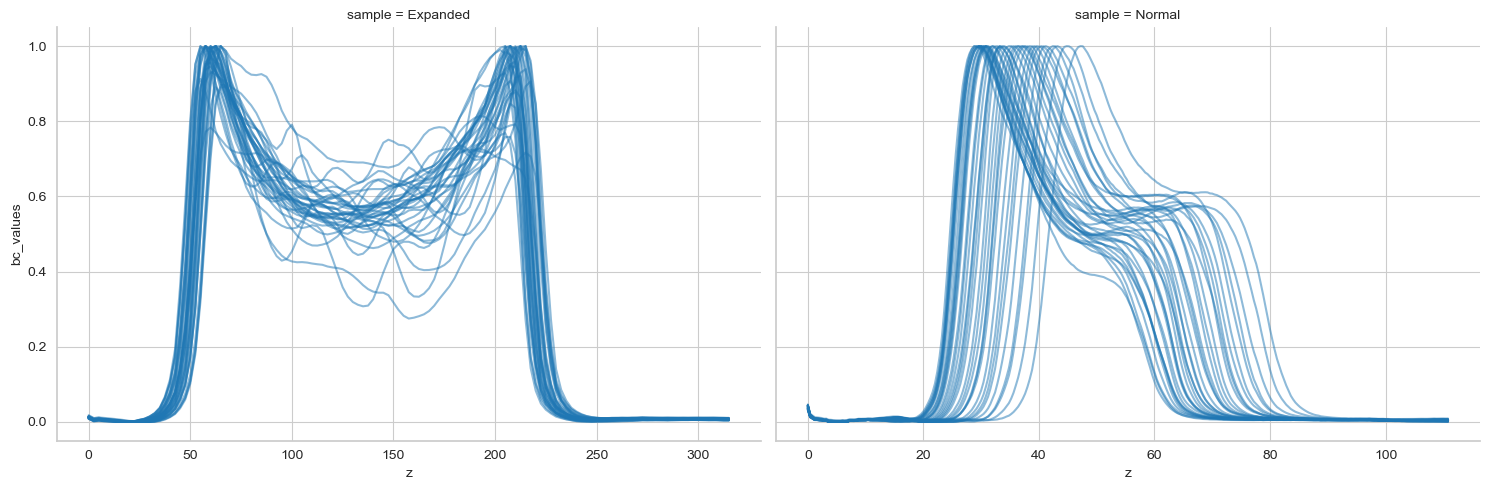

In [13]:
g = sns.FacetGrid(
    long_df,
    col='sample',
    col_order=[expanded_dset.name, normal_dset.name],
    sharex=False,
    sharey=True,
    margin_titles=True,
    height=5,
    aspect=1.5,
)
g.map_dataframe(
    sns.lineplot,
    'z',
    'bc_values',
    units='loc_id',
    estimator=None,
    alpha=0.5,)

In [22]:
%matplotlib notebook

for sample in plane_df['sample'].unique():
    top_arr = None
    bottom_arr = None
    top_points = None
    bottom_points = None
    sample_filter = plane_df['sample'] == sample
    for loc in plane_df['z_loc'].unique():

        loc_filter = plane_df['z_loc'] == loc
        sub_df = plane_df.loc[loc_filter & sample_filter, :]
        pivot = sub_df.pivot(index='y', columns='x', values='z')
        arr = pivot.to_numpy()
        points = skso.Points(sub_df[['x', 'y', 'z']].to_numpy())
        if loc == 'top':
            top_arr = arr
            top_points = points
        else:
            bottom_arr = arr
            bottom_points = points
        plt.figure(figsize=(5, 4))
        sns.heatmap(pivot)

    top_plane_obf = skso.Plane.best_fit(top_points)
    bottom_plane_obf = skso.Plane.best_fit(bottom_points)
    center_plane_obf = skso.Plane.best_fit(
        np.concat([top_points.data, bottom_points.data], axis=0)
    )

    sksplt.plot_3d(
        top_points.plotter(color='g', s=50),
        top_plane_obf.plotter(color='g', alpha=0.5,
                              lims_x=analysis_extent_um, lims_y=analysis_extent_um),
        bottom_points.plotter(color='r', s=50),
        bottom_plane_obf.plotter(color='r', alpha=0.5,
                                 lims_x=analysis_extent_um, lims_y=analysis_extent_um),
        center_plane_obf.plotter(color='k', alpha=0.5,
                                 lims_x=analysis_extent_um, lims_y=analysis_extent_um),
    )
    break



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
n = center_plane_obf.normal
ref = skso.Vector([0, 0, 1])
u2 = n.cross(ref).unit()
u3 = n.cross(u2).unit()

R = np.stack([u2.to_array(), u3.to_array(), n.to_array()], axis=1)

new_top_points = skso.Points(np.matmul(top_points, R))
new_bottom_points = skso.Points(np.matmul(bottom_points, R))
new_top_plane_obf = skso.Plane.best_fit(new_top_points)
new_bottom_plane_obf = skso.Plane.best_fit(new_bottom_points)
all_new_points = skso.Points(
    np.concatenate([new_top_points.data, new_bottom_points.data], axis=0)
)
new_center_plane_obf = skso.Plane.best_fit(all_new_points)

sksplt.plot_3d(
    top_points.plotter(color='g', s=50),
    top_plane_obf.plotter(color='g', alpha=0.5,
                          lims_x=analysis_extent_um, lims_y=analysis_extent_um),
    new_top_points.plotter(color='r', s=50),
    new_top_plane_obf.plotter(color='r', alpha=0.5,
                          lims_x=analysis_extent_um, lims_y=analysis_extent_um),
    center_plane_obf.plotter(color='g', alpha=0.5,
                             lims_x=analysis_extent_um, lims_y=analysis_extent_um),
    new_center_plane_obf.plotter(color='r', alpha=0.5,
                                 lims_x=analysis_extent_um, lims_y=analysis_extent_um),
    new_bottom_points.plotter(color='r', s=50),
    new_bottom_plane_obf.plotter(color='r', alpha=0.5,
                                 lims_x=analysis_extent_um, lims_y=analysis_extent_um),
)

<IPython.core.display.Javascript object>

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

In [52]:
center_plane_obf

Plane(point=Point([ 0.        ,  0.        , 47.82222222]), normal=Vector([-0.02443529, -0.06239225,  0.99775254]))

In [56]:
def set_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.

    Input
      ax: a matplotlib axis, e.g., as output from plt.gca().
    """

    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # The plot bounding box is a sphere in the sense of the infinity
    # norm, hence I call half the max range the plot radius.
    plot_radius = 0.5*max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])



plt.close('all')
line = skso.Line(point=center_plane_obf.point,
                 direction=center_plane_obf.normal)
top_point = top_plane_obf.intersect_line(line)
bottom_point = bottom_plane_obf.intersect_line(line)
line_seg = skso.LineSegment(top_point, bottom_point)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
line_seg.plot_3d(ax)
top_point.plot_3d(ax)
bottom_point.plot_3d(ax)
center_plane_obf.plot_3d(ax,
                         lims_x=analysis_extent_um, lims_y=analysis_extent_um)
top_plane_obf.plot_3d(ax,
                      lims_x=analysis_extent_um, lims_y=analysis_extent_um)
bottom_plane_obf.plot_3d(ax,
                         lims_x=analysis_extent_um, lims_y=analysis_extent_um)
set_axes_equal(ax)

<IPython.core.display.Javascript object>

Figure generated and saved; done.


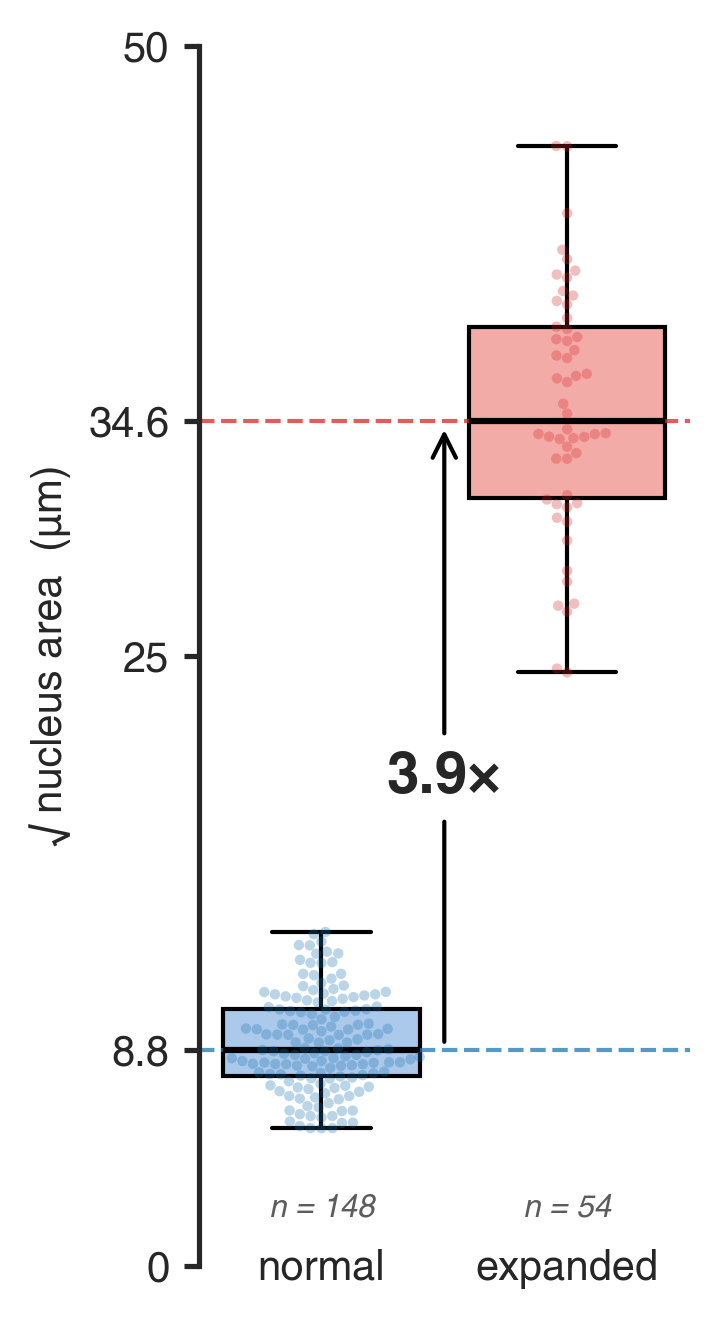

In [7]:
# 3.7.1 generate main figure object
fig = plt.figure(
    figsize=(2.5, 4.5),
    dpi=300)

# 3.7.2 set color palettes
palette_p = sns.color_palette(
    [sns.color_palette('pastel')[0],
     sns.color_palette('pastel')[3]])
palette_n = sns.color_palette(
    [sns.color_palette()[0],
     sns.color_palette()[3]])

# 3.7.3 use seaborn to plot boxplots with overlaid swarmplots from data
ax = sns.boxplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    palette=palette_p,
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name],
    linecolor='k',
    medianprops={'lw': 1.5})
sns.swarmplot(
    data=nuc_size_df,
    x=category_key,
    y=sqrt_area_key,
    hue=category_key,
    size=2.5,
    alpha=0.3,
    ax=ax,
    palette=palette_n,
    color='k',
    order=[unexpanded_cat_name, expanded_cat_name],
    hue_order=[unexpanded_cat_name, expanded_cat_name])

# 3.7.4 plot horizontal lines at the category medians
ax.axhline(
    y=unexm_median,
    color=palette_n[0],
    ls='--',
    lw=1,
    alpha=0.75
)
ax.axhline(
    y=exm_median,
    color=palette_n[1],
    ls='--',
    lw=1,
    alpha=0.75
)

# 3.7.5 format look of axes
sns.despine(right=True, bottom=True, top=True)
ax.set_ylim(0, 50)
ax.spines['bottom'].set_bounds(0, 1)
ax.set_yticks(
    [0, 
     unexm_median,
     25,
     exm_median,
     50])
ax.set_yticklabels(
    ['0',
     f'{unexm_median:.1f}',
     '25',
     f'{exm_median:.1f}',
    '50'])
ax.set_ylabel('\u221A nucleus area  (\u00b5m)')
ax.set_xlabel(None)
ax.tick_params(axis='x', length=0, pad=-4)

# 3.7.6 annotate expansion factor
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, exm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    size=14,
    weight='bold',
)
ax.annotate(
    f'{ex_factor:.1f}\u00D7',
    xy=(0.5, unexm_median),
    xytext=(0.5, 20.0),
    arrowprops=dict(
        arrowstyle='-',
        color='black',
    ),
    annotation_clip=False,
    ha='center',
    va='center',
    alpha=0,
    size=14,
    weight='bold',
)

# 3.7.8 annotate num data points
ax.text(
    0, 2, 
    f'n = {unexm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)
ax.text(
    1, 2, 
    f'n = {exm_n}',
    ha='center',
    va='baseline',
    size=7.5,
    style='oblique',
    alpha=0.75)

# 3.7.9 helper function for saving figure to pdf
def save_figures(
    filename=None, 
    figs=None, 
    dpi=200, 
    fmt='pdf', 
    directory=None,
    add_filename_timestamp=True, 
    stamp_kwargs=None):
    from matplotlib.backends.backend_pdf import PdfPages

    if filename is None:
        filename = 'all_figures'

    if add_filename_timestamp:
        filename = filename + '_' + time.strftime('%y%m%d-%H%M')

    if figs is None:
        figs = [plt.figure(n) for n in plt.get_fignums()]
    else:
        try:
            _ = iter(figs)
        except TypeError:
            figs = [figs, ]

    if stamp_kwargs:
        [stamp_fig(fig, **stamp_kwargs) for fig in figs]

    directory = 'figures' if directory is None else directory
    try:
        os.mkdir(directory)
    except FileExistsError:
        pass

    file_path = os.path.join(directory, filename)
    if fmt == 'pdf':
        file_path += '.pdf'
        with PdfPages(file_path) as pp:
            for fig in figs:
                fig.savefig(pp, format='pdf', dpi=dpi)
    else:
        for i, fig in enumerate(figs):
            fig.savefig('%s_%d.%s' % (file_path, i, fmt), format=fmt, dpi=dpi)

# 3.7.10 perform final layout of plot
plt.tight_layout()

# 3.7.11 export figure to pdf
save_figures(
    filename=figure_name,
    add_filename_timestamp=False,
    directory=figure_dir)

print('Figure generated and saved; done.')

## 4 Notebook Conversion 
This notebook can be converted to a `.pdf` via the following [**pandoc** (https://pandoc.org/)](https://pandoc.org/) 
command:

*for Unix-style command line:*
```bash
pandoc -o "supplementary_file_03-nuc-area.pdf" \  
    --pdf-engine=xelatex --highlight-style tango \
    -V geometry:landscape \
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in
    supplementary_file_03-nuc-area.ipynb
```

*for Windows Command Prompt:*
```
pandoc -o "supplementary_file_03-nuc-area.pdf" ^
    --pdf-engine=xelatex --highlight-style tango ^
    -V geometry:landscape ^
    -V geometry:top=0.75in,bottom=0.75in,left=1in,right=2in ^
    supplementary_file_03-nuc-area.ipynb
    
```